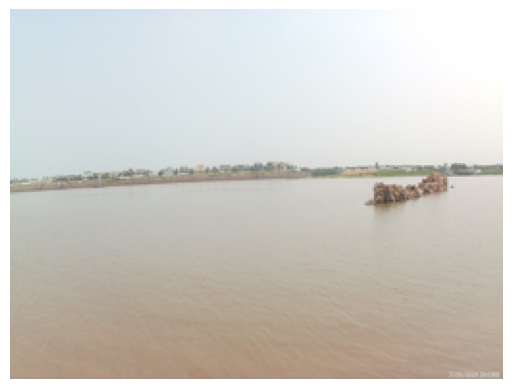

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# Open an image file
image_path = '/home/tille/Proyectos/Tesis/code/assets/images/akaso2.jpeg'
image = Image.open(image_path)
# Resize the image to 256x192 pixels
image = image.resize((256, 192))
# Display the image
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()


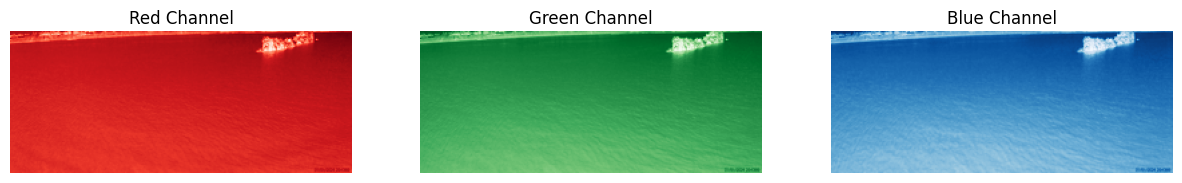

In [6]:
import numpy as np
# Convertir la imagen a un array numpy
image_array = np.array(image)

# Separar los canales RGB
red_channel = image_array[86:, :, 0]
green_channel = image_array[86:, :, 1]
blue_channel = image_array[86:, :, 2]

# Mostrar los canales separados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(red_channel, cmap='Reds')
axes[0].set_title('Red Channel')
axes[0].axis('off')

axes[1].imshow(green_channel, cmap='Greens')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(blue_channel, cmap='Blues')
axes[2].set_title('Blue Channel')
axes[2].axis('off')

plt.show()

In [14]:
red_channel.flatten()

array([202, 203, 203, ..., 174, 173, 168], dtype=uint8)

In [15]:
import statistics
from time import time
a = time()
print("Red: ",np.bincount(red_channel.flatten()).argmax())
print("Green: ",np.bincount(green_channel.flatten()).argmax())
print("Blue: ",np.bincount(blue_channel.flatten()).argmax())
b = time()

print(1/(b-a))

Red:  177
Green:  192
Blue:  194
823.8664309565901


In [43]:
red_channel[red_channel < 177-30].shape

(347,)

In [38]:
green_channel[green_channel < 192-60].shape

(309,)

In [42]:
blue_channel[blue_channel < 194-80].shape

(250,)

In [ ]:
from collections import Counter

# Convert the image to a list of pixels
pixels = list(image.getdata())

# Count the occurrences of each pixel
pixel_counts = Counter(pixels)

# Create a sorted list of pixels by occurrence in descending order
sorted_pixel_counts = sorted(pixel_counts.items(), key=lambda x: x[1], reverse=True)

# Display the sorted list of pixels with their occurrences
for pixel, count in sorted_pixel_counts:
    print(f'Pixel: {pixel}, Occurrences: {count}')

Pixel: (255, 255, 255), Occurrences: 1203
Pixel: (254, 254, 254), Occurrences: 231
Pixel: (213, 223, 225), Occurrences: 132
Pixel: (212, 222, 224), Occurrences: 117
Pixel: (214, 223, 228), Occurrences: 110
Pixel: (252, 252, 254), Occurrences: 72
Pixel: (211, 221, 223), Occurrences: 72
Pixel: (214, 224, 226), Occurrences: 71
Pixel: (224, 235, 241), Occurrences: 70
Pixel: (214, 225, 231), Occurrences: 70
Pixel: (224, 233, 238), Occurrences: 68
Pixel: (215, 224, 229), Occurrences: 68
Pixel: (211, 224, 230), Occurrences: 64
Pixel: (223, 232, 237), Occurrences: 59
Pixel: (215, 226, 232), Occurrences: 59
Pixel: (222, 231, 236), Occurrences: 59
Pixel: (221, 231, 233), Occurrences: 56
Pixel: (216, 227, 233), Occurrences: 55
Pixel: (208, 218, 219), Occurrences: 54
Pixel: (253, 253, 255), Occurrences: 53
Pixel: (210, 224, 233), Occurrences: 49
Pixel: (210, 220, 222), Occurrences: 49
Pixel: (209, 219, 220), Occurrences: 49
Pixel: (245, 250, 254), Occurrences: 48
Pixel: (248, 252, 255), Occurrence

In [33]:
pixels

[(202, 222, 236),
 (204, 222, 234),
 (204, 221, 235),
 (204, 222, 236),
 (204, 222, 234),
 (205, 222, 235),
 (205, 221, 236),
 (204, 222, 236),
 (204, 222, 236),
 (204, 222, 235),
 (205, 223, 236),
 (204, 222, 236),
 (204, 222, 236),
 (204, 223, 235),
 (206, 222, 236),
 (204, 222, 236),
 (204, 222, 236),
 (204, 222, 235),
 (205, 223, 237),
 (206, 222, 237),
 (206, 222, 237),
 (205, 223, 237),
 (205, 222, 237),
 (206, 222, 238),
 (206, 223, 237),
 (205, 222, 237),
 (205, 223, 237),
 (205, 223, 237),
 (205, 223, 237),
 (206, 224, 236),
 (205, 223, 237),
 (206, 222, 237),
 (208, 222, 238),
 (207, 222, 238),
 (206, 222, 237),
 (207, 222, 237),
 (208, 222, 238),
 (208, 222, 238),
 (208, 223, 238),
 (207, 223, 238),
 (207, 223, 238),
 (207, 223, 238),
 (209, 222, 238),
 (209, 222, 238),
 (209, 222, 238),
 (210, 223, 239),
 (209, 222, 238),
 (209, 222, 239),
 (210, 223, 238),
 (208, 224, 237),
 (210, 224, 239),
 (211, 223, 238),
 (211, 224, 238),
 (211, 225, 239),
 (209, 225, 239),
 (209, 225

In [35]:
import numpy as np

# Convert the list of pixels to a numpy array for easier manipulation
pixels_array = np.array(pixels)

# Define the initial centroids (we'll use the first, middle, and last pixel as initial centroids)
centroids = np.array([pixels_array[256*(192//4)+(256//2)], pixels_array[len(pixels_array) // 2+(256//2)], pixels_array[256*(192//4*3)+(256//2)]])
# centroids = np.array([pixels_array[0], pixels_array[-1]])

# Function to calculate the euclidean distance between two points
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

# Function to assign pixels to the nearest centroid
def assign_pixels_to_centroids(pixels, centroids):
    clusters = {i: [] for i in range(len(centroids))}
    for pixel in pixels:
        distances = [euclidean_distance(pixel, centroid) for centroid in centroids]
        closest_centroid = np.argmin(distances)
        clusters[closest_centroid].append(pixel)
    return clusters

# Assign pixels to the nearest centroid
clusters = assign_pixels_to_centroids(pixels_array, centroids)

# Print the number of pixels in each cluster
for i, cluster in clusters.items():
    print(f'Cluster {i+1}: {len(cluster)} pixels')

Cluster 1: 20598 pixels
Cluster 2: 10228 pixels
Cluster 3: 18326 pixels


In [36]:
centroids

array([[224, 234, 236],
       [201, 200, 195],
       [182, 170, 154]])

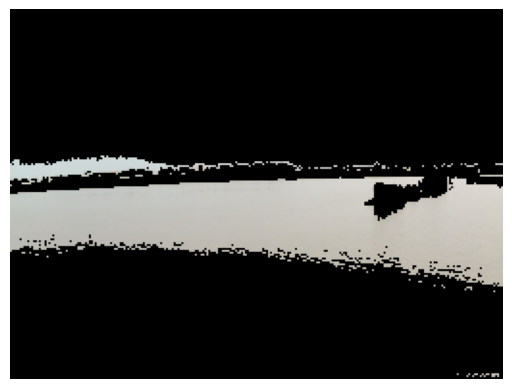

In [40]:
# Crear una copia de la imagen original
image_cluster_1 = image.copy()
pixels_cluster_1 = image_cluster_1.load()

# Obtener los píxeles del cluster 1
cluster_1_pixels = set(map(tuple, clusters[1]))

# Recorrer cada píxel de la imagen y pintar de negro los que no estén en el cluster 1
for y in range(image_cluster_1.height):
    for x in range(image_cluster_1.width):
        if pixels_cluster_1[x, y] not in cluster_1_pixels:
            pixels_cluster_1[x, y] = (0, 0, 0)

# Mostrar la imagen resultante
plt.imshow(image_cluster_1)
plt.axis('off')  # Ocultar los ejes
plt.show()

In [55]:
# Obtener los píxeles de la imagen redimensionada
pixels_resized = list(image.getdata())

# Convertir los píxeles a un array numpy para facilitar la manipulación
pixels_resized_array = np.array(pixels_resized).reshape((192, 256, 3))

# Extraer los píxeles de la izquierda, derecha y centro
left_pixels = pixels_resized_array[76:116, 0, :].tolist()
right_pixels = pixels_resized_array[76:116, -1, :].tolist()
center_pixels = pixels_resized_array[76:116, 256 // 2, :].tolist()

# Mostrar las listas de píxeles
print("Left Pixels:", left_pixels)
print("Right Pixels:", right_pixels)
print("Center Pixels:", center_pixels)

Left Pixels: [[206, 220, 220], [205, 220, 219], [208, 219, 219], [207, 219, 219], [204, 218, 219], [205, 218, 218], [204, 219, 216], [203, 218, 215], [202, 218, 215], [204, 216, 214], [202, 217, 215], [202, 212, 206], [197, 199, 190], [136, 143, 142], [137, 142, 136], [203, 204, 185], [149, 149, 129], [172, 165, 150], [152, 142, 134], [173, 172, 164], [195, 202, 194], [195, 201, 195], [195, 202, 198], [194, 202, 197], [194, 201, 195], [195, 202, 194], [193, 200, 193], [192, 199, 192], [191, 199, 192], [190, 199, 192], [190, 196, 192], [191, 194, 188], [191, 192, 187], [189, 193, 187], [190, 193, 187], [190, 192, 185], [189, 193, 186], [189, 193, 186], [188, 191, 185], [186, 189, 183]]
Right Pixels: [[237, 234, 227], [235, 232, 225], [234, 231, 225], [234, 231, 224], [215, 213, 210], [141, 143, 146], [132, 136, 134], [143, 146, 130], [140, 147, 119], [141, 147, 125], [202, 200, 189], [226, 220, 213], [224, 220, 210], [223, 219, 212], [222, 218, 212], [222, 217, 211], [221, 216, 210], [2

In [47]:
192//2

96

In [ ]:
def find_largest_jump(pixels_list):
    max_jump = 0
    max_jump_index = 0
    for i in range(1, len(pixels_list)):
        jump = np.linalg.norm(np.array(pixels_list[i]) - np.array(pixels_list[i-1]))
        if jump > max_jump:
            max_jump = jump
            max_jump_index = i + 76
    return max_jump_index

# Encontrar el salto más grande en cada lista de píxeles
left_max_jump_index = find_largest_jump(left_pixels)
right_max_jump_index = find_largest_jump(right_pixels)
center_max_jump_index = find_largest_jump(center_pixels)

print(f'Left Pixels Max Jump Index: {left_max_jump_index}')
print(f'Right Pixels Max Jump Index: {right_max_jump_index}')
print(f'Center Pixels Max Jump Index: {center_max_jump_index}')

In [58]:
def fuzzy_difference(a, b):
    return np.sum(np.abs(a - b))

def find_largest_fuzzy_jump(pixels_list):
    max_jump = 0
    max_jump_index = 0
    for i in range(1, len(pixels_list)):
        jump = fuzzy_difference(np.array(pixels_list[i]), np.array(pixels_list[i-1]))
        if jump > max_jump:
            max_jump = jump
            max_jump_index = i + 76
    return max_jump_index

# Encontrar el salto más grande en cada lista de píxeles utilizando lógica difusa
left_max_fuzzy_jump_index = find_largest_fuzzy_jump(left_pixels)
right_max_fuzzy_jump_index = find_largest_fuzzy_jump(right_pixels)
center_max_fuzzy_jump_index = find_largest_fuzzy_jump(center_pixels)

print(f'Left Pixels Max Fuzzy Jump Index: {left_max_fuzzy_jump_index}')
print(f'Right Pixels Max Fuzzy Jump Index: {right_max_fuzzy_jump_index}')
print(f'Center Pixels Max Fuzzy Jump Index: {center_max_fuzzy_jump_index}')

Left Pixels Max Fuzzy Jump Index: 91
Right Pixels Max Fuzzy Jump Index: 81
Center Pixels Max Fuzzy Jump Index: 89


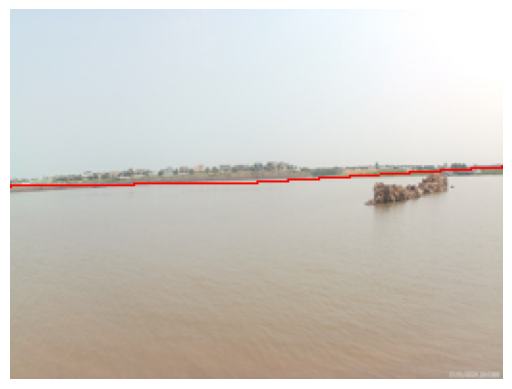

In [62]:
from PIL import ImageDraw

# Crear una copia de la imagen redimensionada original
image_with_lines = image.copy()
draw = ImageDraw.Draw(image_with_lines)

# Obtener las coordenadas de los puntos
left_point = (0, left_max_fuzzy_jump_index)
center_point = (256//2,center_max_fuzzy_jump_index)
right_point = (255, right_max_fuzzy_jump_index)

# Dibujar las líneas que conectan los puntos
draw.line([left_point,center_point, right_point], fill="red", width=2)

# Mostrar la imagen resultante
plt.imshow(image_with_lines)
plt.axis('off')  # Ocultar los ejes
plt.show()

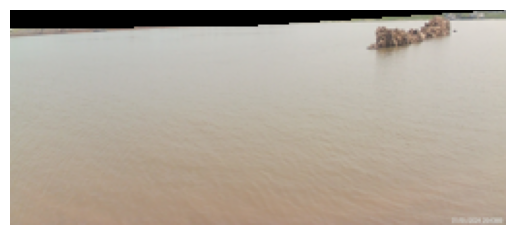

In [68]:
# Crear una máscara para la parte inferior de la imagen
mask = Image.new('L', image.size, 0)
draw_mask = ImageDraw.Draw(mask)
draw_mask.polygon([left_point, center_point, right_point, (image.width, image.height), (0, image.height)], fill=255)

# Aplicar la máscara a la imagen original
image_below_line = Image.composite(image, Image.new('RGB', image.size, (0, 0, 0)), mask)

# Recortar la imagen para eliminar la parte negra de arriba
min_y = min(left_point[1], center_point[1], right_point[1])
cropped_image = image_below_line.crop((0, min_y, image.width, image.height))

# Mostrar la imagen resultante
plt.imshow(cropped_image)
plt.axis('off')  # Ocultar los ejes
plt.show()

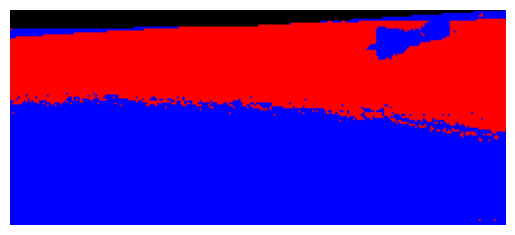

In [72]:
def initialize_membership_matrix(n_pixels, n_clusters):
    membership_matrix = np.random.dirichlet(np.ones(n_clusters), size=n_pixels)
    return membership_matrix

def calculate_cluster_centers(pixels, membership_matrix, n_clusters, m):
    cluster_centers = []
    for j in range(n_clusters):
        numerator = np.sum((membership_matrix[:, j] ** m)[:, np.newaxis] * pixels, axis=0)
        denominator = np.sum(membership_matrix[:, j] ** m)
        cluster_centers.append(numerator / denominator)
    return np.array(cluster_centers)

def update_membership_matrix(pixels, cluster_centers, n_clusters, m, height, width):
    membership_matrix = np.zeros((len(pixels), n_clusters))
    for i in range(len(pixels)):
        if np.array_equal(pixels[i], [0, 0, 0]):
            continue
        for j in range(n_clusters):
            numerator = np.linalg.norm(pixels[i] - cluster_centers[j])
            denominator = np.sum([(numerator / np.linalg.norm(pixels[i] - cluster_centers[k])) ** (2 / (m - 1)) for k in range(n_clusters)])
            membership_matrix[i, j] = 1 / denominator
        # Adjust membership based on vertical position
        y = i // width
        membership_matrix[i, 0] *= (1 + y / height)  # Increase probability of water for lower pixels
        membership_matrix[i, 1] *= (1 - y / height)  # Decrease probability of stones for lower pixels
    return membership_matrix

def fuzzy_c_means(pixels, n_clusters, m=2, max_iter=100, error=1e-5):
    n_pixels = len(pixels)
    height = cropped_image.height
    width = cropped_image.width
    membership_matrix = initialize_membership_matrix(n_pixels, n_clusters)
    for _ in range(max_iter):
        cluster_centers = calculate_cluster_centers(pixels, membership_matrix, n_clusters, m)
        new_membership_matrix = update_membership_matrix(pixels, cluster_centers, n_clusters, m, height, width)
        if np.linalg.norm(new_membership_matrix - membership_matrix) < error:
            break
        membership_matrix = new_membership_matrix
    return cluster_centers, membership_matrix

# Convertir la imagen recortada a una lista de píxeles
cropped_pixels = list(cropped_image.getdata())
cropped_pixels_array = np.array(cropped_pixels)

# Aplicar Fuzzy C-Means para segmentar los píxeles del agua y las piedras
n_clusters = 2  # Agua y piedras
cluster_centers, membership_matrix = fuzzy_c_means(cropped_pixels_array, n_clusters)

# Asignar cada píxel al cluster con mayor pertenencia
segmented_pixels = np.argmax(membership_matrix, axis=1)

# Crear una nueva imagen segmentada
segmented_image = cropped_image.copy()
segmented_pixels_image = segmented_image.load()

for y in range(segmented_image.height):
    for x in range(segmented_image.width):
        pixel_index = y * segmented_image.width + x
        if np.array_equal(cropped_pixels_array[pixel_index], [0, 0, 0]):
            continue
        if segmented_pixels[pixel_index] == 0:
            segmented_pixels_image[x, y] = (0, 0, 255)  # Agua en azul
        else:
            segmented_pixels_image[x, y] = (255, 0, 0)  # Piedras en rojo

# Mostrar la imagen segmentada
plt.imshow(segmented_image)
plt.axis('off')  # Ocultar los ejes
plt.show()